285.77396651458844
309.09602345622784
308.2039575982643


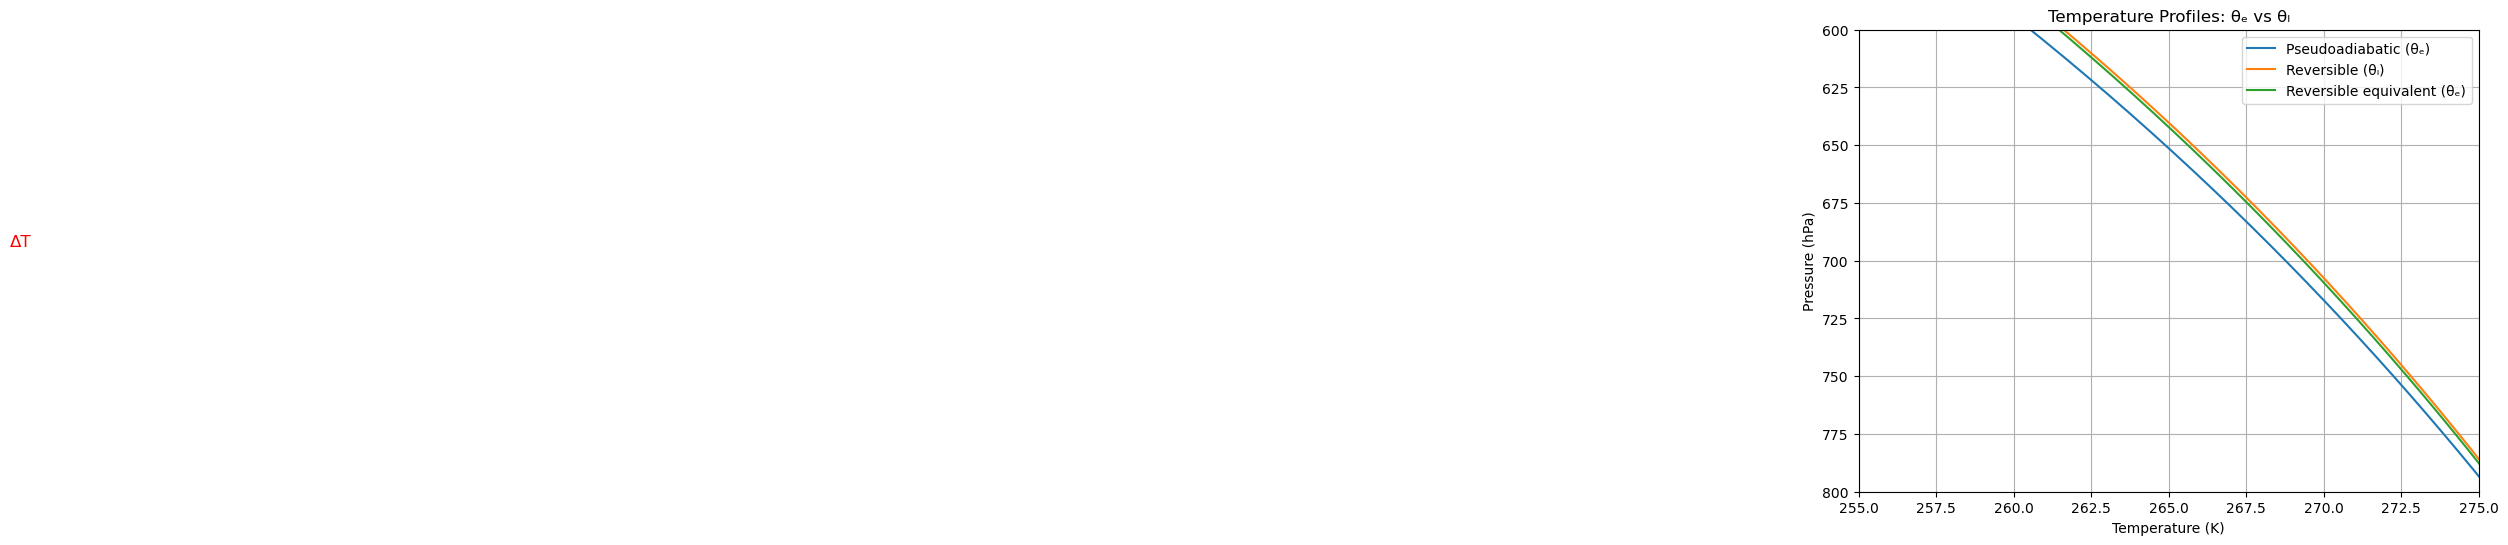

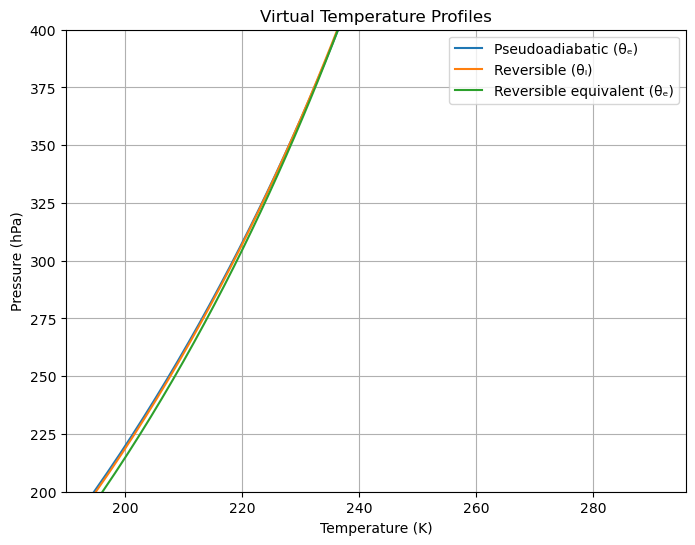

In [1]:
import numpy as np
from scipy.optimize import newton

# Constants
Rd = 287.04       # Gas constant for dry air [J/kg/K]
Rv = 461.5        # Gas constant for water vapor [J/kg/K]
cpd = 1005.0      # Specific heat of dry air [J/kg/K]
cpv = 2010.0      # Specific heat of water vapor [J/kg/K]
cl = 4218.0       # Specific heat of liquid water [J/kg/K]
Lv0 = 2.501e6     # Latent heat of vaporization [J/kg]
p0 = 1000.0e2     # Reference pressure [Pa]
epsilon = Rd / Rv  # Ratio of gas constants

# Define saturation vapor pressure (T in K, output in Pa)
def esat(T):
    return 611.2 * np.exp(17.67 * (T - 273.15) / (T - 29.65))

# Compute qv_sat (p in Pa, T in K)
def qv_sat(p, T):
    es = esat(T)
    return epsilon * es / (p - (1 - epsilon) * es)

# Lifting Condensation Level (LCL) calculation
def compute_lcl(T_surface, qt, p_surface):
    def f(T_lcl):
        return qt - qv_sat(p_surface * (T_lcl / T_surface)**(Rd / (cpd + qt * cl)), T_lcl)
    T_lcl = newton(f, T_surface)
    p_lcl = p_surface * (T_lcl / T_surface)**(Rd / (cpd + qt * cl))
    return T_lcl, p_lcl

# Theta_e (pseudoadiabatic) -- Bolton (1980) approximation
def theta_e(T, p, qt):
    qv = min(qt, qv_sat(p, T))  # Saturation adjustment
    ql = max(0.0, qt - qv)
    theta = T * (p0 / p)**(Rd / cpd)
    return theta * np.exp(Lv0 * qv / (cpd * T)) * (1 - ql)**(-Rd / cpd)

# Theta_l (reversible) -- Liquid water potential temperature
def theta_l(T, p, qt):
    qv = min(qt, qv_sat(p, T))  # Saturation adjustment
    ql = max(0.0, qt - qv)
    poisson = 0.2854*(1 - 0.24*qv)
    theta = T * (p0 / p)**(poisson)
    return theta * ((epsilon + qv) / (epsilon + qt))**poisson * (qv/qt)**(-qt*Rv / (cpd + qt * cpv)) * np.exp(-Lv0 * ql / ((cpd + qt * cpv) * T))


def theta_e_reversible(T, p, qt):
    qv = min(qt, qv_sat(p, T))  # Saturation adjustment
    ql = max(0.0, qt - qv)
    # Reversible equivalent temperature formula
    theta = T * (p0 / p)**(Rd / (cpd + qt * cl))
    return theta * np.exp(Lv0 * qv / ((cpd + qt * cl) * T))


# Compute temperature profile for given theta_e or theta_l
def compute_profile(p_surface, T_surface, qt, theta_type='theta_e', n_levels=100):
    p = np.linspace(p_surface, 200.0e2, n_levels)  # Pressure levels [Pa]
    T = np.zeros_like(p)
    T[0] = T_surface
    
    # Compute LCL
    T_lcl, p_lcl = compute_lcl(T_surface, qt, p_surface)
    
    for i in range(1, len(p)):
        if p[i] > p_lcl:
            # Unsaturated: dry adiabat
            T[i] = T_surface * (p[i] / p_surface)**(Rd / cpd)
        else:
            # Saturated: follow theta_e, theta_l, or theta_e_reversible
            if theta_type == 'theta_e':
                def f(T_new):
                    return theta_e(T_new, p[i], qt) - theta_e(T_lcl, p_lcl, qt)
            elif theta_type == 'theta_l':
                def f(T_new):
                    return theta_l(T_new, p[i], qt) - theta_l(T_lcl, p_lcl, qt)
            elif theta_type == 'theta_e_reversible':
                def f(T_new):
                    return theta_e_reversible(T_new, p[i], qt) - theta_e_reversible(T_lcl, p_lcl, qt)
            else:
                raise ValueError(f"Unknown theta_type: {theta_type}")
            T[i] = newton(f, T[i-1])
    
    return p, T



# Example usage
p_surface = 1000.0e2  # 1000 hPa in Pa
T_surface = 289     # 300 K
qt = 0.009           # Total water mixing ratio (9 g/kg)

print(theta_l(compute_lcl(T_surface, qt, p_surface)[0],compute_lcl(T_surface, qt, p_surface)[1], qt))
print(theta_e(compute_lcl(T_surface, qt, p_surface)[0],compute_lcl(T_surface, qt, p_surface)[1], qt))
print(theta_e_reversible(compute_lcl(T_surface, qt, p_surface)[0],compute_lcl(T_surface, qt, p_surface)[1], qt))
# Compute profiles
p_pseudo, T_pseudo = compute_profile(p_surface, T_surface, qt, theta_type='theta_e')
p_l, T_l = compute_profile(p_surface, T_surface, qt, theta_type='theta_l')
p_e, T_e = compute_profile(p_surface, T_surface, qt, theta_type='theta_e_reversible')

# Plot results
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

plt.figure(figsize=(8, 6))
plt.plot(T_pseudo, p_pseudo / 100, label='Pseudoadiabatic (θₑ)')
plt.plot(T_l, p_l / 100, label='Reversible (θₗ)')
plt.plot(T_e, p_e / 100, label='Reversible equivalent (θₑ)')
# Choose a pressure level slightly above 700 hPa (e.g., 690 hPa)
target_pressure = 690  # in hPa

# Interpolate or find temperature values at this pressure
# (Assumes T_pseudo, T_l, and p_pseudo are NumPy arrays)
import numpy as np
T_pseudo_interp = np.interp(target_pressure, p_pseudo / 100, T_pseudo)
T_l_interp = np.interp(target_pressure, p_l / 100, T_l)

# Add the red two-headed arrow
arrow = FancyArrowPatch(
    (T_pseudo_interp, target_pressure),  # Start at blue line
    (T_l_interp, target_pressure),       # End at green line
    arrowstyle='<->',
    color='red',
    mutation_scale=15,
    linewidth=2
)
plt.gca().add_patch(arrow)

# Optionally, add a label showing the difference
plt.text(
    (T_pseudo_interp + T_l_interp) / 2,
    target_pressure + 5,  # slightly above the arrow
    'ΔT',
    color='red',
    ha='center',
    va='bottom',
    fontsize=12
)

plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (hPa)')
plt.title('Temperature Profiles: θₑ vs θₗ')
plt.legend()
plt.xlim(255,275)
plt.ylim(600,800)
plt.gca().invert_yaxis()
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(T_pseudo*(1+np.minimum(qt,0.61*qv_sat(p_pseudo, T_pseudo))), p_pseudo / 100, label='Pseudoadiabatic (θₑ)')
plt.plot(T_l*(1+0.61*np.minimum(qt, qv_sat(p_l, T_l)) - np.maximum(0.0, qt - np.minimum(qt, qv_sat(p_l, T_l)))), p_l / 100, label='Reversible (θₗ)')
plt.plot(T_e*(1+0.61*np.minimum(qt, qv_sat(p_e, T_e)) - np.maximum(0.0, qt - np.minimum(qt, qv_sat(p_e, T_e)))), p_e / 100, label='Reversible equivalent (θₑ)')
plt.gca().invert_yaxis()
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (hPa)')
plt.title('Virtual Temperature Profiles')
#plt.xlim(240,260)
plt.ylim(200,400)
plt.legend()
plt.grid()
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


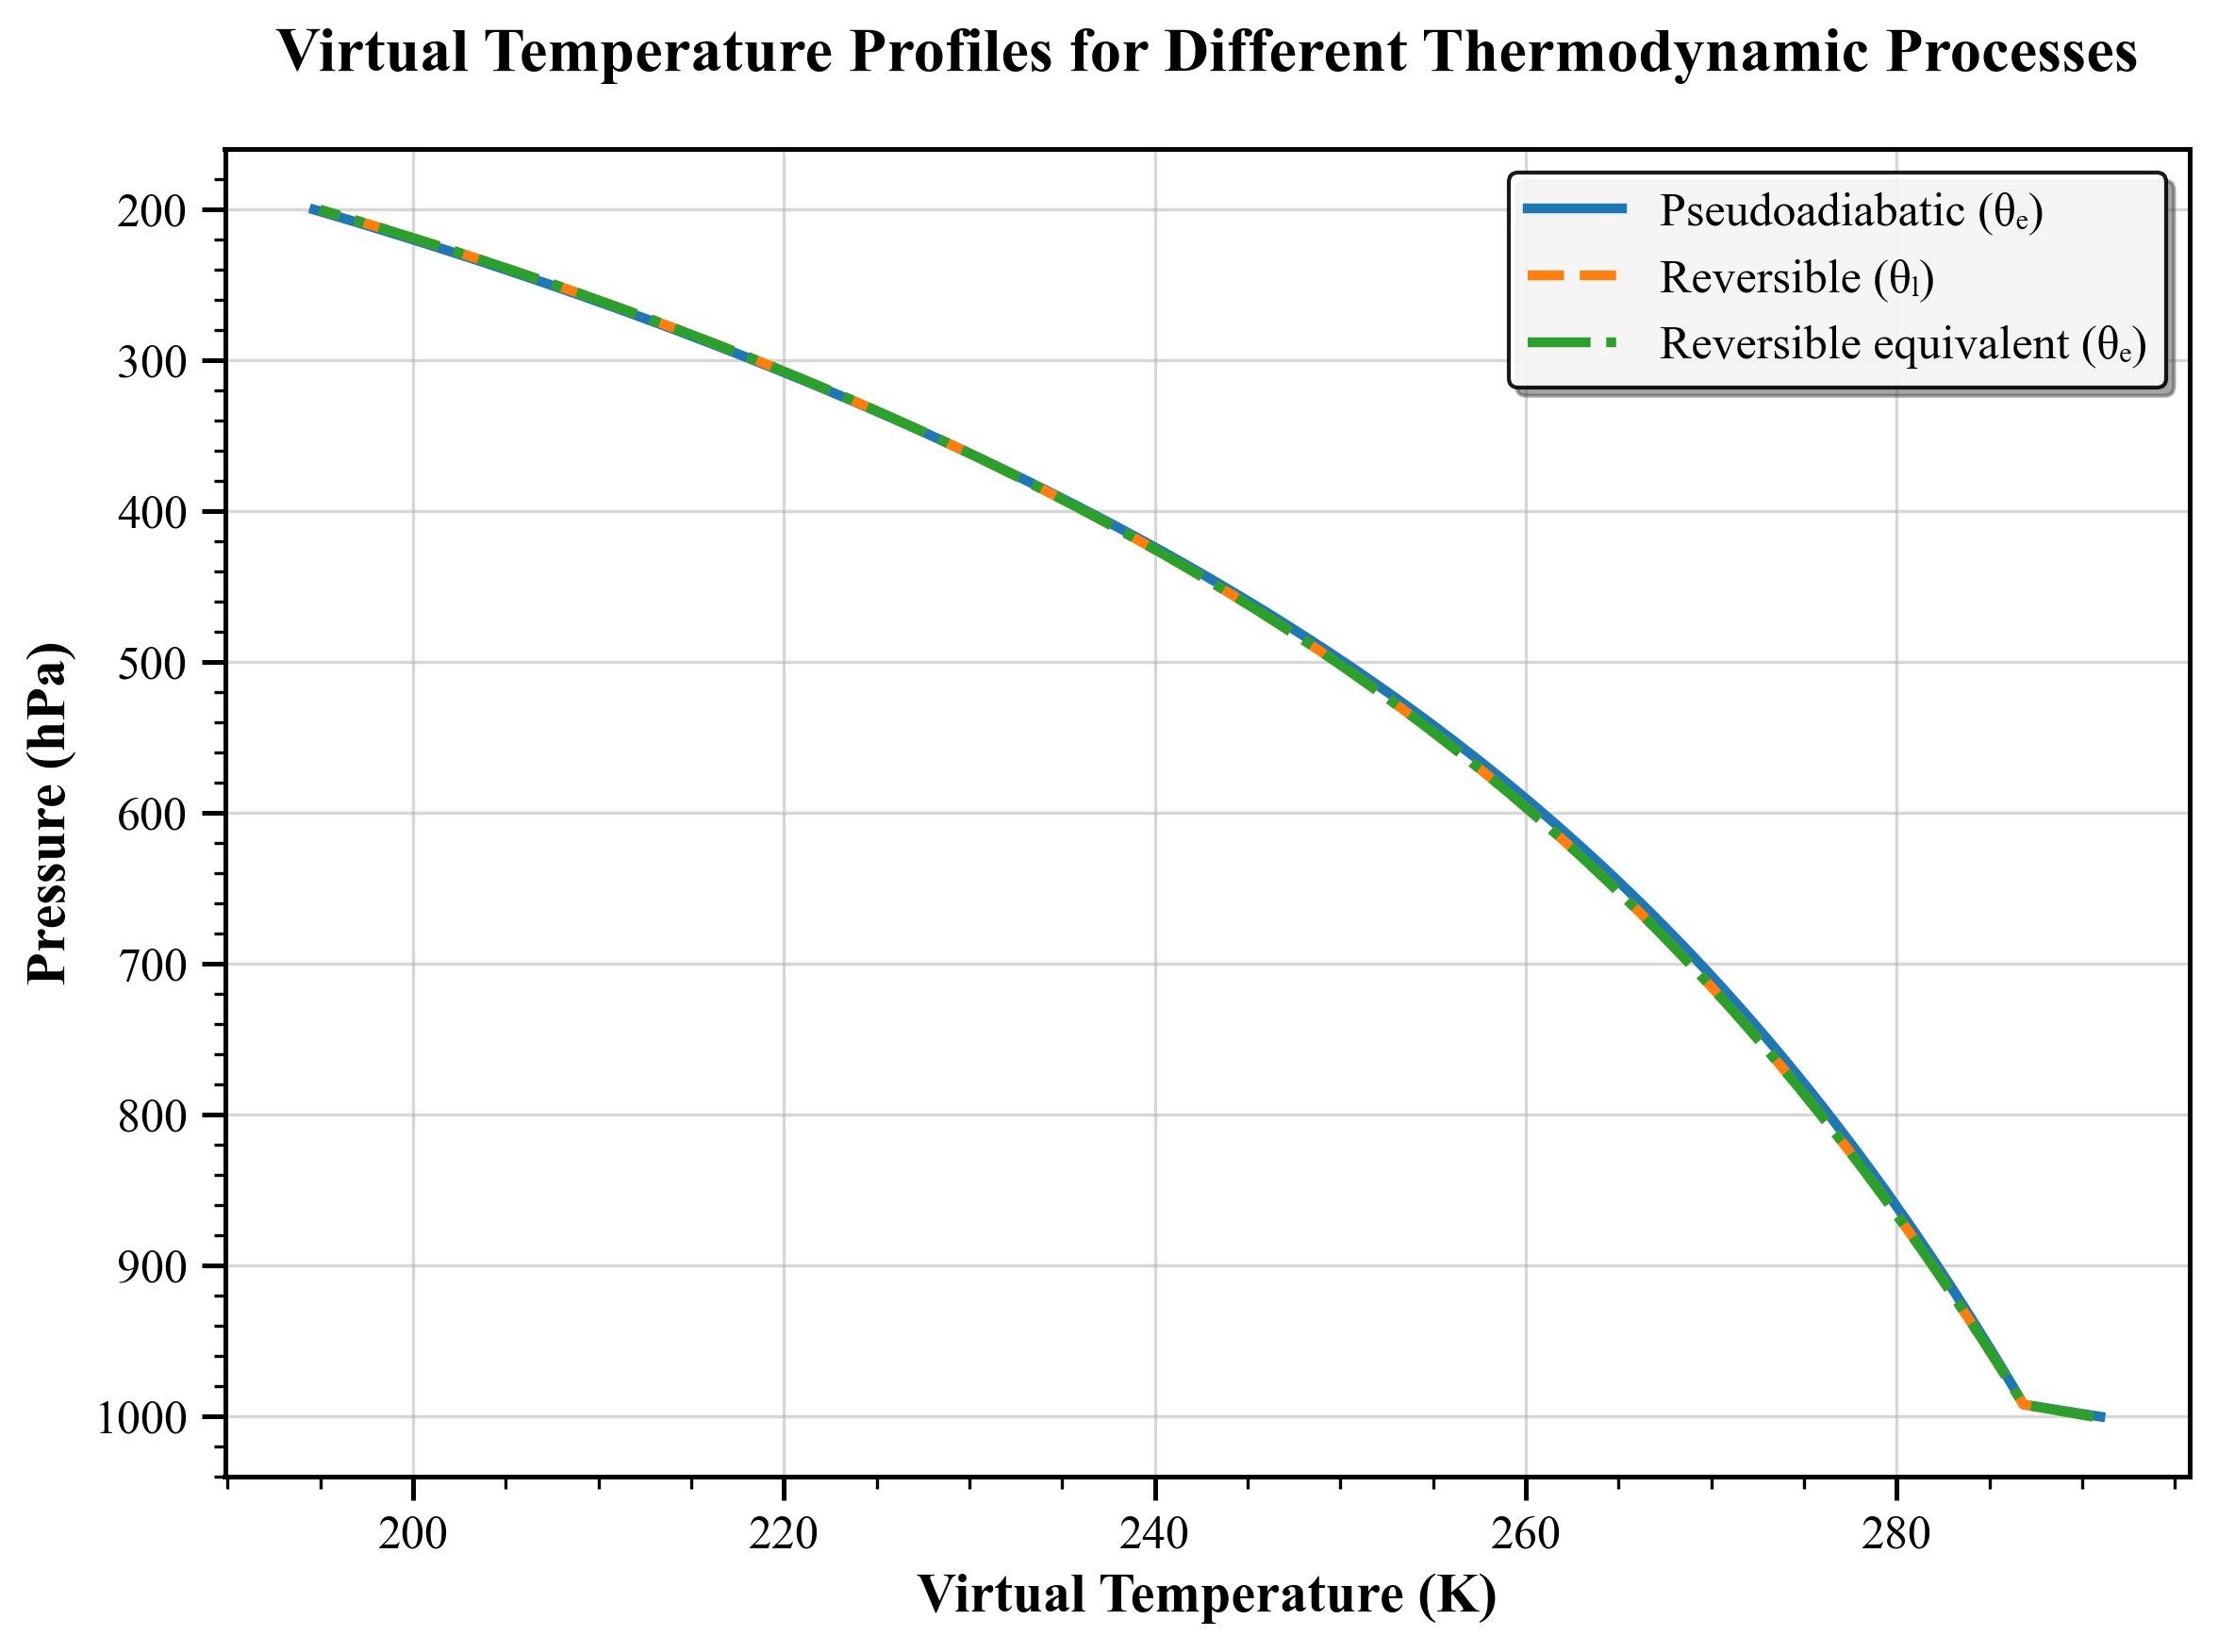

In [2]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

fig, ax = plt.subplots(figsize=(8, 6))

# Your plot with improved styling
ax.plot(T_pseudo*(1+np.minimum(qt,0.61*qv_sat(p_pseudo, T_pseudo))), 
        p_pseudo / 100, 
        linewidth=2.5, 
        color='#1f77b4',  # Professional blue
        label='Pseudoadiabatic (θₑ)')

ax.plot(T_l*(1+0.61*np.minimum(qt, qv_sat(p_l, T_l)) - np.maximum(0.0, qt - np.minimum(qt, qv_sat(p_l, T_l)))), 
        p_l / 100, 
        linewidth=2.5, 
        color='#ff7f0e',  # Professional orange
        linestyle='--',
        label='Reversible (θₗ)')

ax.plot(T_l*(1+0.61*np.minimum(qt, qv_sat(p_e, T_e)) - np.maximum(0.0, qt - np.minimum(qt, qv_sat(p_l, T_l)))), 
        p_l / 100, 
        linewidth=2.5, 
        color='#2ca02c',  # Professional green
        linestyle='-.',
        label='Reversible equivalent (θₑ)')

# Improved formatting
ax.invert_yaxis()
ax.set_xlabel('Virtual Temperature (K)', fontweight='bold')
ax.set_ylabel('Pressure (hPa)', fontweight='bold')
ax.set_title('Virtual Temperature Profiles for Different Thermodynamic Processes', 
             fontweight='bold', pad=20)

# Better axis limits and ticks
#ax.set_ylim(400, 200)  # Note: inverted, so high to low
#ax.set_xlim(240, 280)  # Adjust based on your data range

# Professional grid
ax.grid(True, alpha=0.5, linewidth=0.8)
ax.set_axisbelow(True)  # Grid behind data

# Improved legend
legend = ax.legend(loc='upper right', 
                   frameon=True, 
                   fancybox=True, 
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Add minor ticks
ax.minorticks_on()
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

# Tight layout
plt.tight_layout()

# Save as high-quality formats
plt.savefig('virtual_temp_profiles.png', dpi=300, bbox_inches='tight')
plt.savefig('virtual_temp_profiles.pdf', bbox_inches='tight')  # Vector format for publications
plt.savefig('virtual_temp_profiles.eps', bbox_inches='tight')  # Alternative vector format

plt.show()

# Reset rcParams to default after plotting (optional)
plt.rcParams.update(plt.rcParamsDefault)

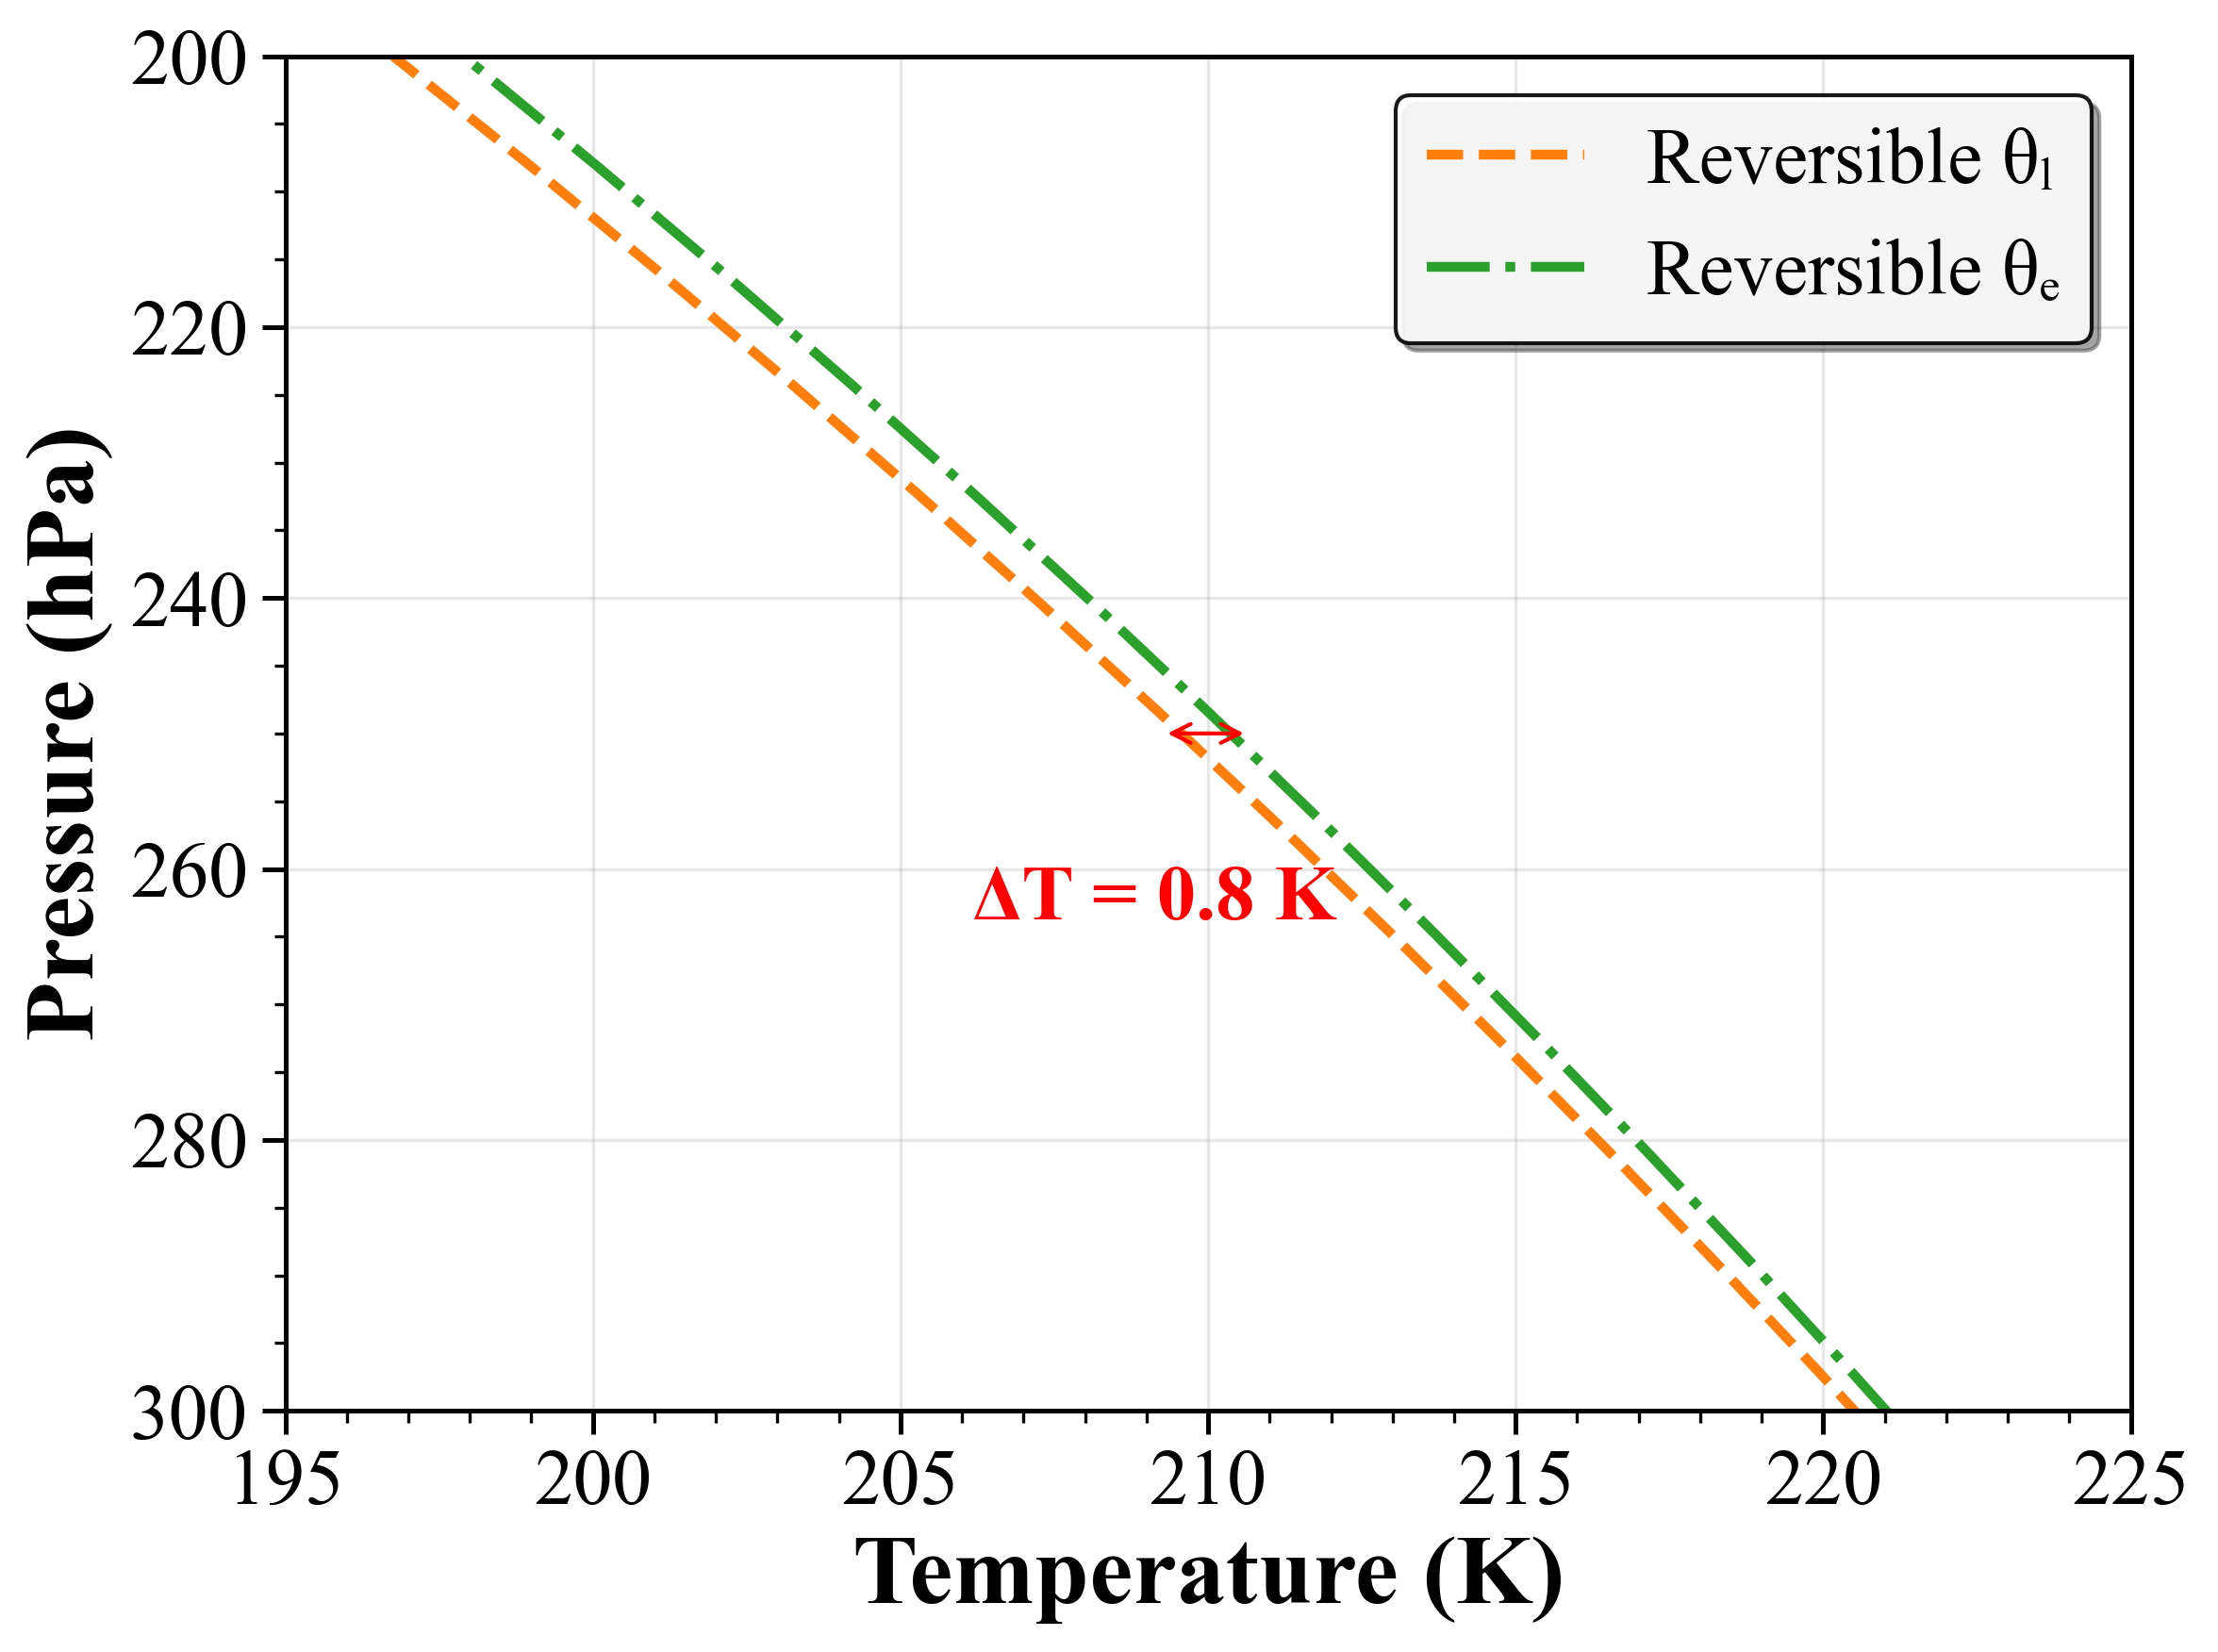

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 25,
    'axes.titlesize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})


fig, ax = plt.subplots(figsize=(8, 6))

# Your original plots
#ax.plot(T_pseudo, p_pseudo / 100, linewidth=2.5, color='#1f77b4', label='Pseudoadiabatic θₑ')
ax.plot(T_l, p_l / 100, linewidth=2.5, color='#ff7f0e', linestyle='--', label='Reversible θₗ')
ax.plot(T_e, p_e / 100, linewidth=2.5, color='#2ca02c', linestyle='-.', label='Reversible θₑ')

# Add ΔT annotations at 300 hPa
target_pressure = 250  # hPa

# Find the closest indices to 300 hPa for each profile
idx_pseudo = np.argmin(np.abs(p_pseudo / 100 - target_pressure))
idx_rev = np.argmin(np.abs(p_l / 100 - target_pressure))
idx_l = np.argmin(np.abs(p_e / 100 - target_pressure))

# Get temperatures at 300 hPa for each profile
T_pseudo_300 = T_pseudo[idx_pseudo]
T_l_300 = T_l[idx_rev] 
T_e_300 = T_e[idx_l]

# Add horizontal arrows and ΔT annotations
# Arrow from pseudoadiabatic to reversible θₗ
#ax.annotate('', xy=(T_rev_300, target_pressure), xytext=(T_pseudo_300, target_pressure),
            #arrowprops=dict(arrowstyle='<->', color='red', lw=2))

# ΔT text annotation above the arrow
mid_T_rev = (T_e_300 + T_l_300) / 2
ax.text(mid_T_rev-0.5, target_pressure + 15, f'ΔT = {abs(T_e_300 - T_l_300):.1f} K', 
        ha='center', va='bottom', color='red', fontweight='bold', fontsize=20)

#Arrow from pseudoadiabatic to reversible θₑ  
ax.annotate('', xy=(T_l_300+1.5, target_pressure), xytext=(T_l_300, target_pressure),
            arrowprops=dict(arrowstyle='<->', color='red', lw=1))

# ΔT text annotation above the second arrow
#mid_T_l = (T_pseudo_300 + T_l_300) / 2
#ax.text(mid_T_l, target_pressure + 5, f'ΔT = {abs(T_l_300 - T_pseudo_300):.1f} K', 
        #ha='center', va='bottom', color='red', fontweight='bold', fontsize=12)

# Improved formatting
ax.invert_yaxis()
ax.set_xlabel('Temperature (K)', fontweight='bold')
ax.set_ylabel('Pressure (hPa)', fontweight='bold')
#ax.set_title('Temperature Profiles for Adiabatic Approaches', fontweight='bold', pad=20)

# Better axis limits and ticks
ax.set_ylim(300, 200)  # Note: inverted, so high to low
ax.set_xlim(195, 225)  # Adjust based on your data range

# Professional grid
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)  # Grid behind data

# Improved legend
legend = ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True,
                   framealpha=0.9, edgecolor='black', facecolor='white')

# Add minor ticks
ax.minorticks_on()
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

# Tight layout
plt.tight_layout()

plt.show()

# Reset rcParams to default after plotting (optional)
plt.rcParams.update(plt.rcParamsDefault)

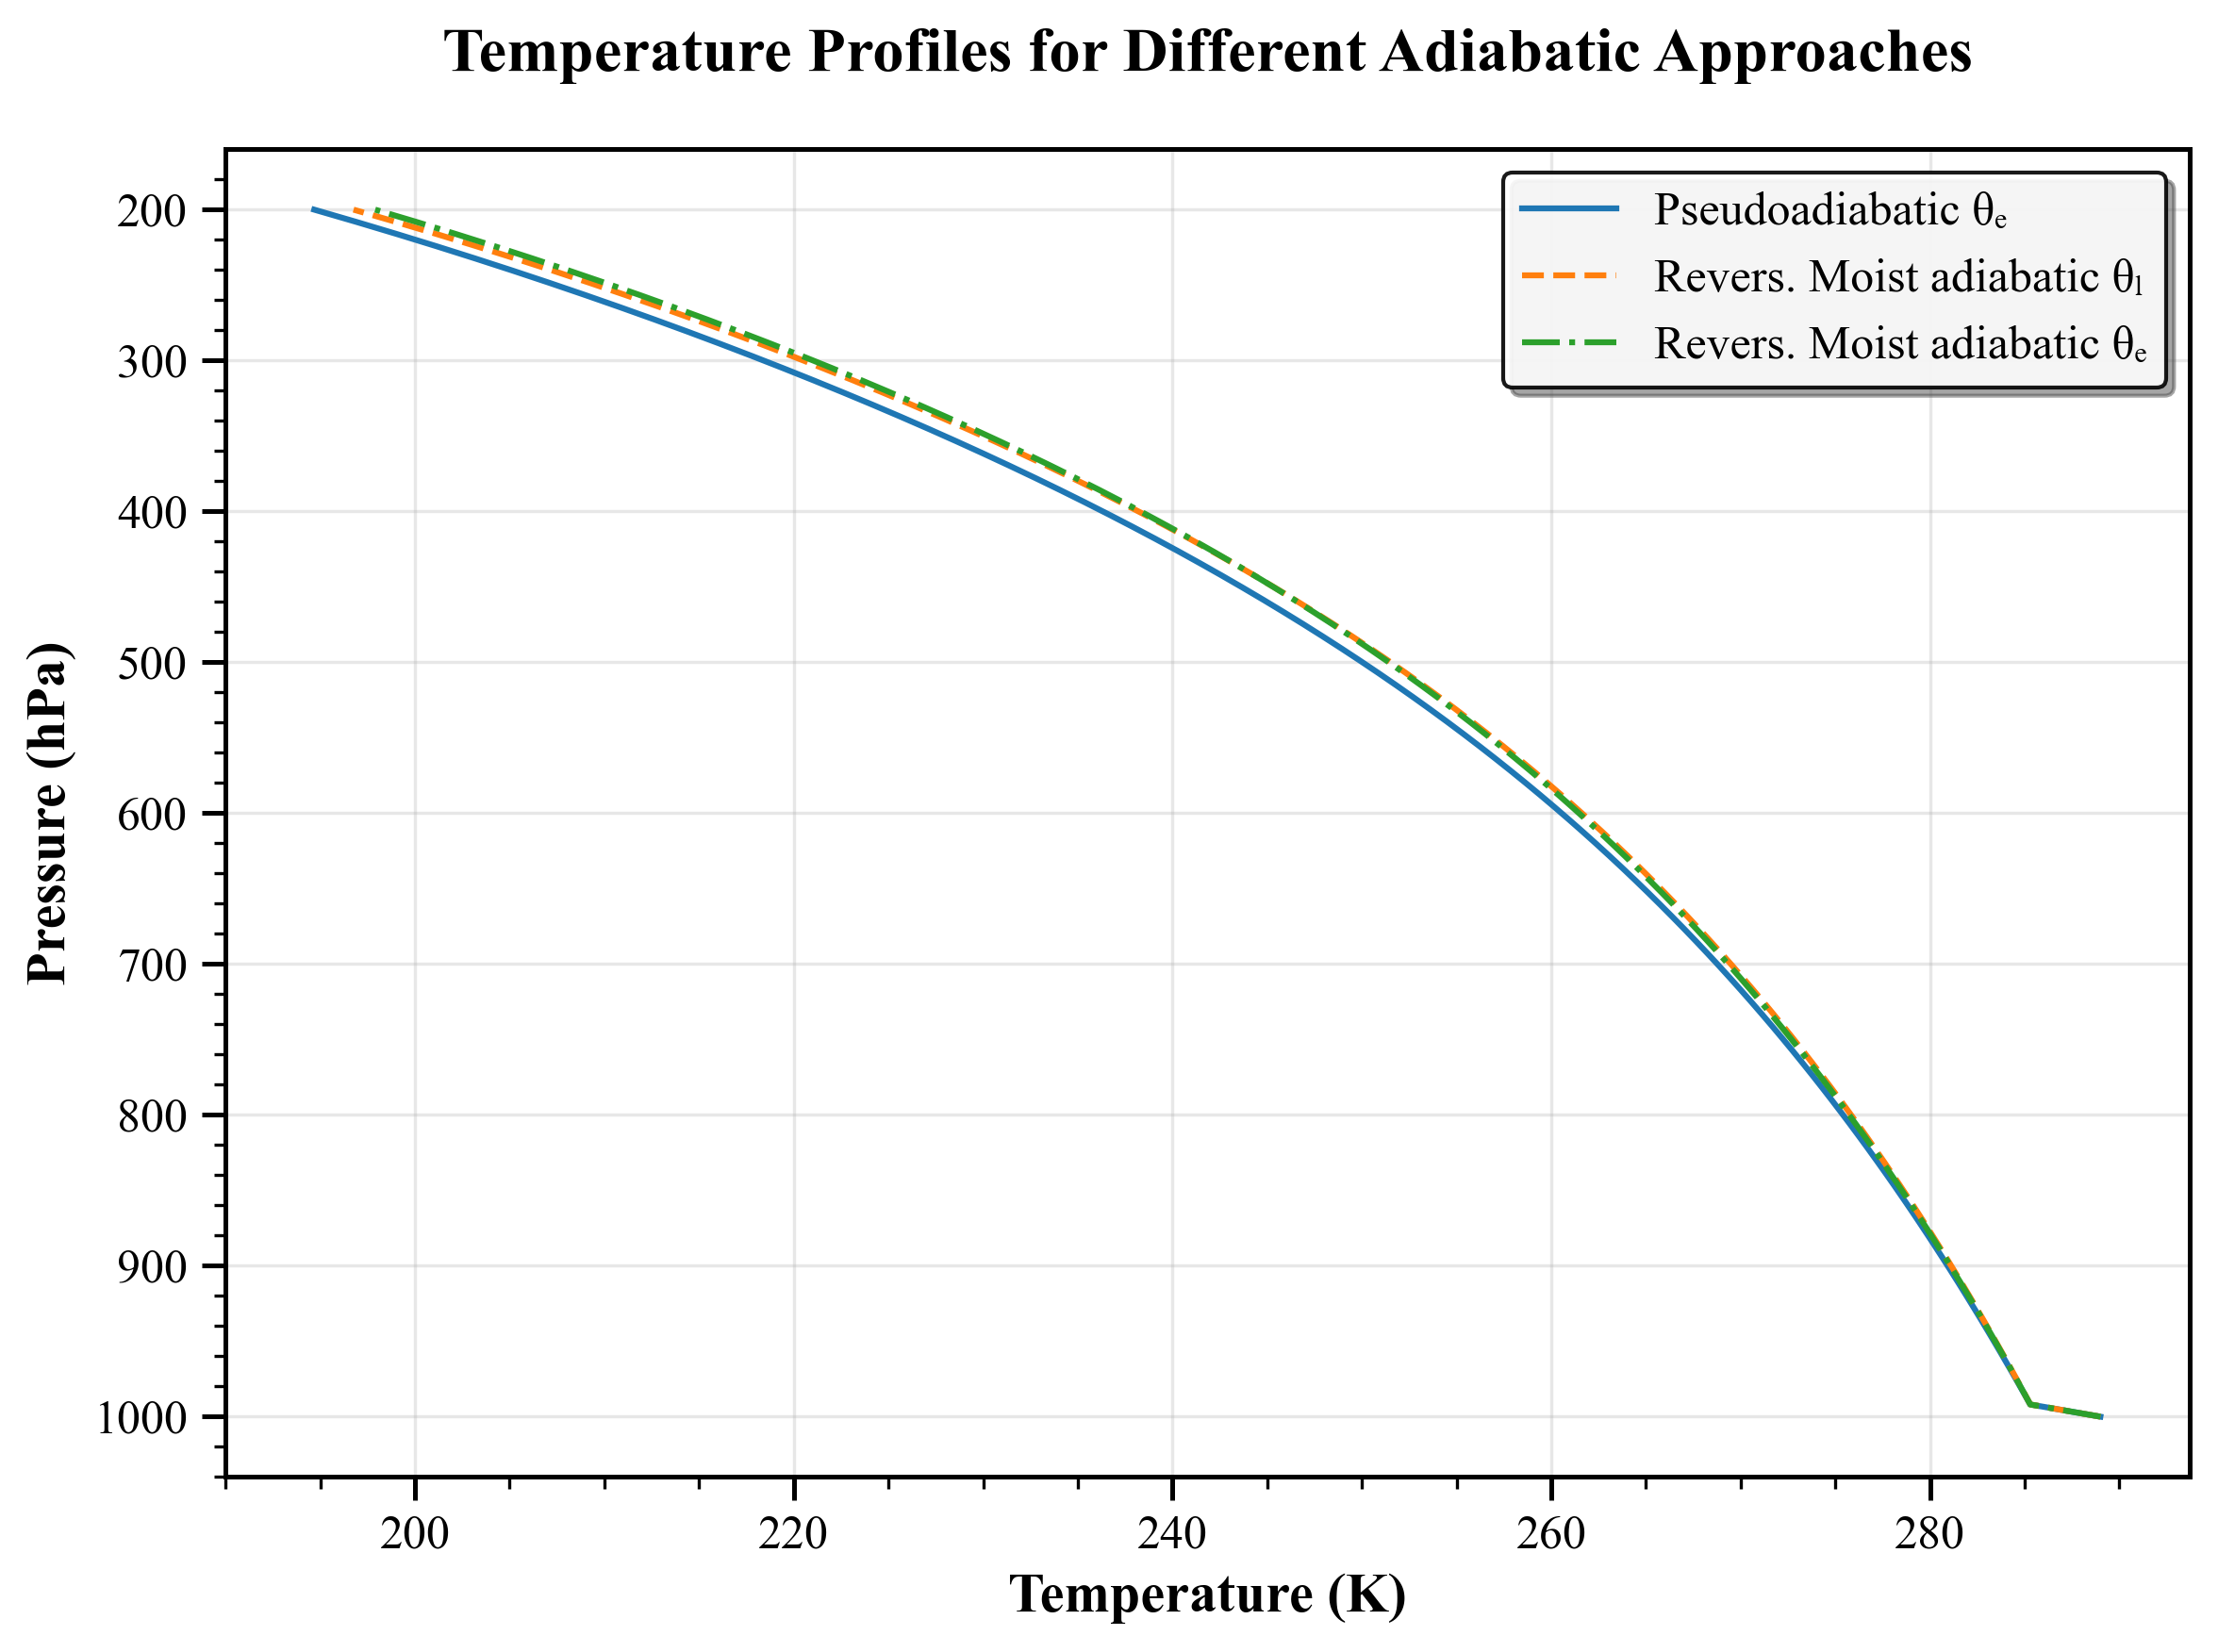

In [4]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

fig, ax = plt.subplots(figsize=(8, 6))

# Your plot with improved styling
ax.plot(T_pseudo, 
        p_pseudo / 100, 
        linewidth=1.5, 
        color='#1f77b4',  # Professional blue
        label='Pseudoadiabatic θₑ')

ax.plot(T_l, 
        p_l / 100, 
        linewidth=1.5, 
        color='#ff7f0e',  # Professional orange
        linestyle='--',
        label='Revers. Moist adiabatic θₗ')

ax.plot(T_e, 
        p_l / 100, 
        linewidth=1.5, 
        color='#2ca02c',  # Professional green
        linestyle='-.',
        label='Revers. Moist adiabatic θₑ')

# Improved formatting
ax.invert_yaxis()
ax.set_xlabel('Temperature (K)', fontweight='bold')
ax.set_ylabel('Pressure (hPa)', fontweight='bold')
ax.set_title('Temperature Profiles for Different Adiabatic Approaches', 
             fontweight='bold', pad=20)

# Better axis limits and ticks
#ax.set_ylim(400, 200)  # Note: inverted, so high to low
#ax.set_xlim(240, 280)  # Adjust based on your data range

# Professional grid
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)  # Grid behind data

# Improved legend
legend = ax.legend(loc='upper right', 
                   frameon=True, 
                   fancybox=True, 
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Add minor ticks
ax.minorticks_on()
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

# Tight layout
plt.tight_layout()

# Save as high-quality formats
#plt.savefig('virtual_temp_profiles.png', dpi=300, bbox_inches='tight')
#plt.savefig('virtual_temp_profiles.pdf', bbox_inches='tight')  # Vector format for publications
#plt.savefig('virtual_temp_profiles.eps', bbox_inches='tight')  # Alternative vector format

plt.show()

# Reset rcParams to default after plotting (optional)
plt.rcParams.update(plt.rcParamsDefault)

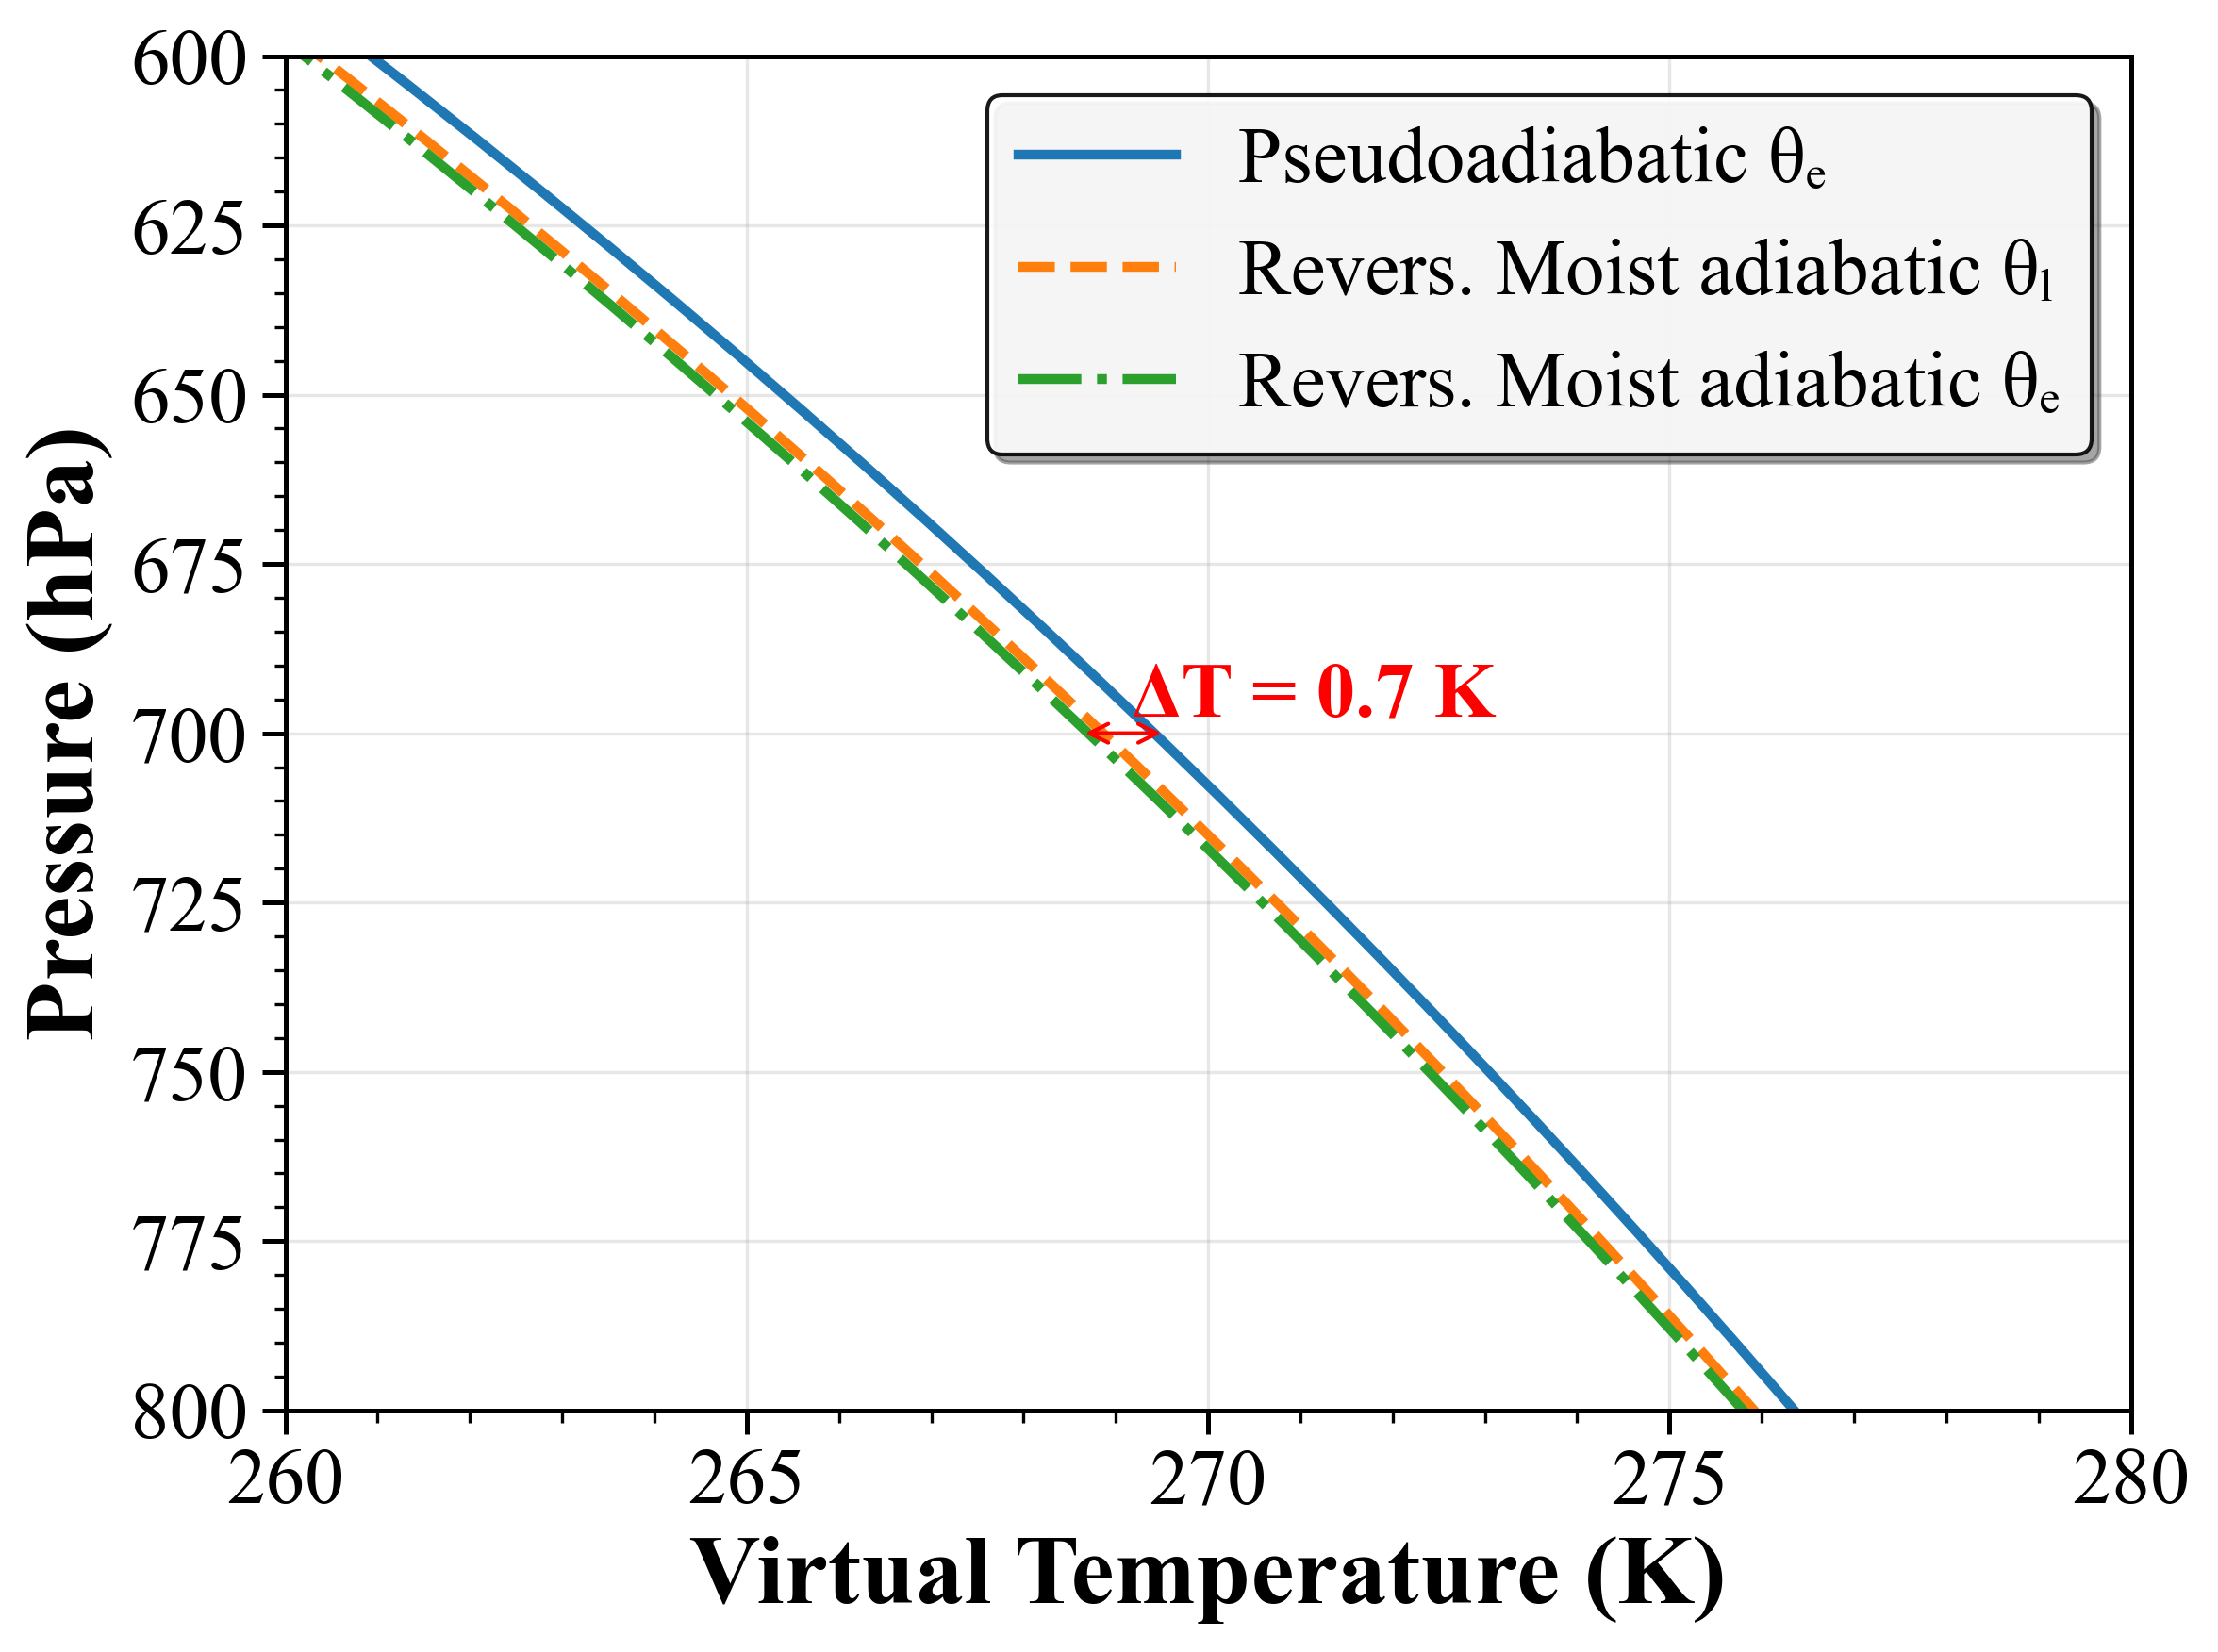

In [36]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 25,
    'axes.titlesize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

fig, ax = plt.subplots(figsize=(8, 6))

# Your plot with improved styling
T_v_pseudo = T_pseudo*(1+np.minimum(qt,0.61*qv_sat(p_pseudo, T_pseudo)))
T_v_e = T_e*(1+0.61*np.minimum(qt, qv_sat(p_e, T_e)) - np.maximum(0.0, qt - np.minimum(qt, qv_sat(p_e, T_e))))
T_v_l = T_l*(1+0.61*np.minimum(qt, qv_sat(p_l, T_l)) - np.maximum(0.0, qt - np.minimum(qt, qv_sat(p_l, T_l))))
ax.plot(T_v_pseudo, 
        p_pseudo / 100, 
        linewidth=2.5, 
        color='#1f77b4',  # Professional blue
        label='Pseudoadiabatic θₑ')

ax.plot(T_v_l, 
        p_l / 100, 
        linewidth=2.5, 
        color='#ff7f0e',  # Professional orange
        linestyle='--',
        label='Revers. Moist adiabatic θₗ')

ax.plot(T_v_e, 
        p_e / 100, 
        linewidth=2.5, 
        color='#2ca02c',  # Professional green
        linestyle='-.',
        label='Revers. Moist adiabatic θₑ')
# Add ΔT annotations at 300 hPa
target_pressure = 700  # hPa

# Find the closest indices to 300 hPa for each profile
idx_pseudo = np.argmin(np.abs(p_pseudo / 100 - target_pressure))
idx_rev = np.argmin(np.abs(p_l / 100 - target_pressure))
idx_l = np.argmin(np.abs(p_e / 100 - target_pressure))

# Get temperatures at 300 hPa for each profile
T_pseudo_300 = T_v_pseudo[idx_pseudo]
T_l_300 = T_v_l[idx_rev] 
T_e_300 = T_v_e[idx_l]

# Add horizontal arrows and ΔT annotations
# Arrow from pseudoadiabatic to reversible θₗ
#ax.annotate('', xy=(T_rev_300, target_pressure), xytext=(T_pseudo_300, target_pressure),
            #arrowprops=dict(arrowstyle='<->', color='red', lw=2))

# ΔT text annotation above the arrow
mid_T_rev = (T_pseudo_300 + T_e_300) / 2
ax.text(mid_T_rev+2, target_pressure, f'ΔT = {abs(T_pseudo_300 - T_e_300):.1f} K', 
        ha='center', va='bottom', color='red', fontweight='bold', fontsize=20)
#Arrow from pseudoadiabatic to reversible θₑ  
ax.annotate('', xy=(T_e_300+0.8, target_pressure), xytext=(T_e_300-0.2, target_pressure),
            arrowprops=dict(arrowstyle='<->', color='red', lw=1))
# Improved formatting
ax.invert_yaxis()
ax.set_xlabel('Virtual Temperature (K)', fontweight='bold')
ax.set_ylabel('Pressure (hPa)', fontweight='bold')
#ax.set_title('Virtual Temperature Profiles for Different Thermodynamic Processes', 
             #fontweight='bold', pad=20)

# Better axis limits and ticks
ax.set_ylim(800, 600)  # Note: inverted, so high to low
ax.set_xlim(260, 280)  # Adjust based on your data range

# Professional grid
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)  # Grid behind data

# Improved legend
legend = ax.legend(loc='upper right', 
                   frameon=True, 
                   fancybox=True, 
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Add minor ticks
ax.minorticks_on()
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

# Tight layout
plt.tight_layout()

# Save as high-quality formats
#plt.savefig('virtual_temp_profiles.png', dpi=300, bbox_inches='tight')
#plt.savefig('virtual_temp_profiles.pdf', bbox_inches='tight')  # Vector format for publications
#plt.savefig('virtual_temp_profiles.eps', bbox_inches='tight')  # Alternative vector format

plt.show()

# Reset rcParams to default after plotting (optional)
plt.rcParams.update(plt.rcParamsDefault)

In [6]:
T_e_300

268.78060058257023

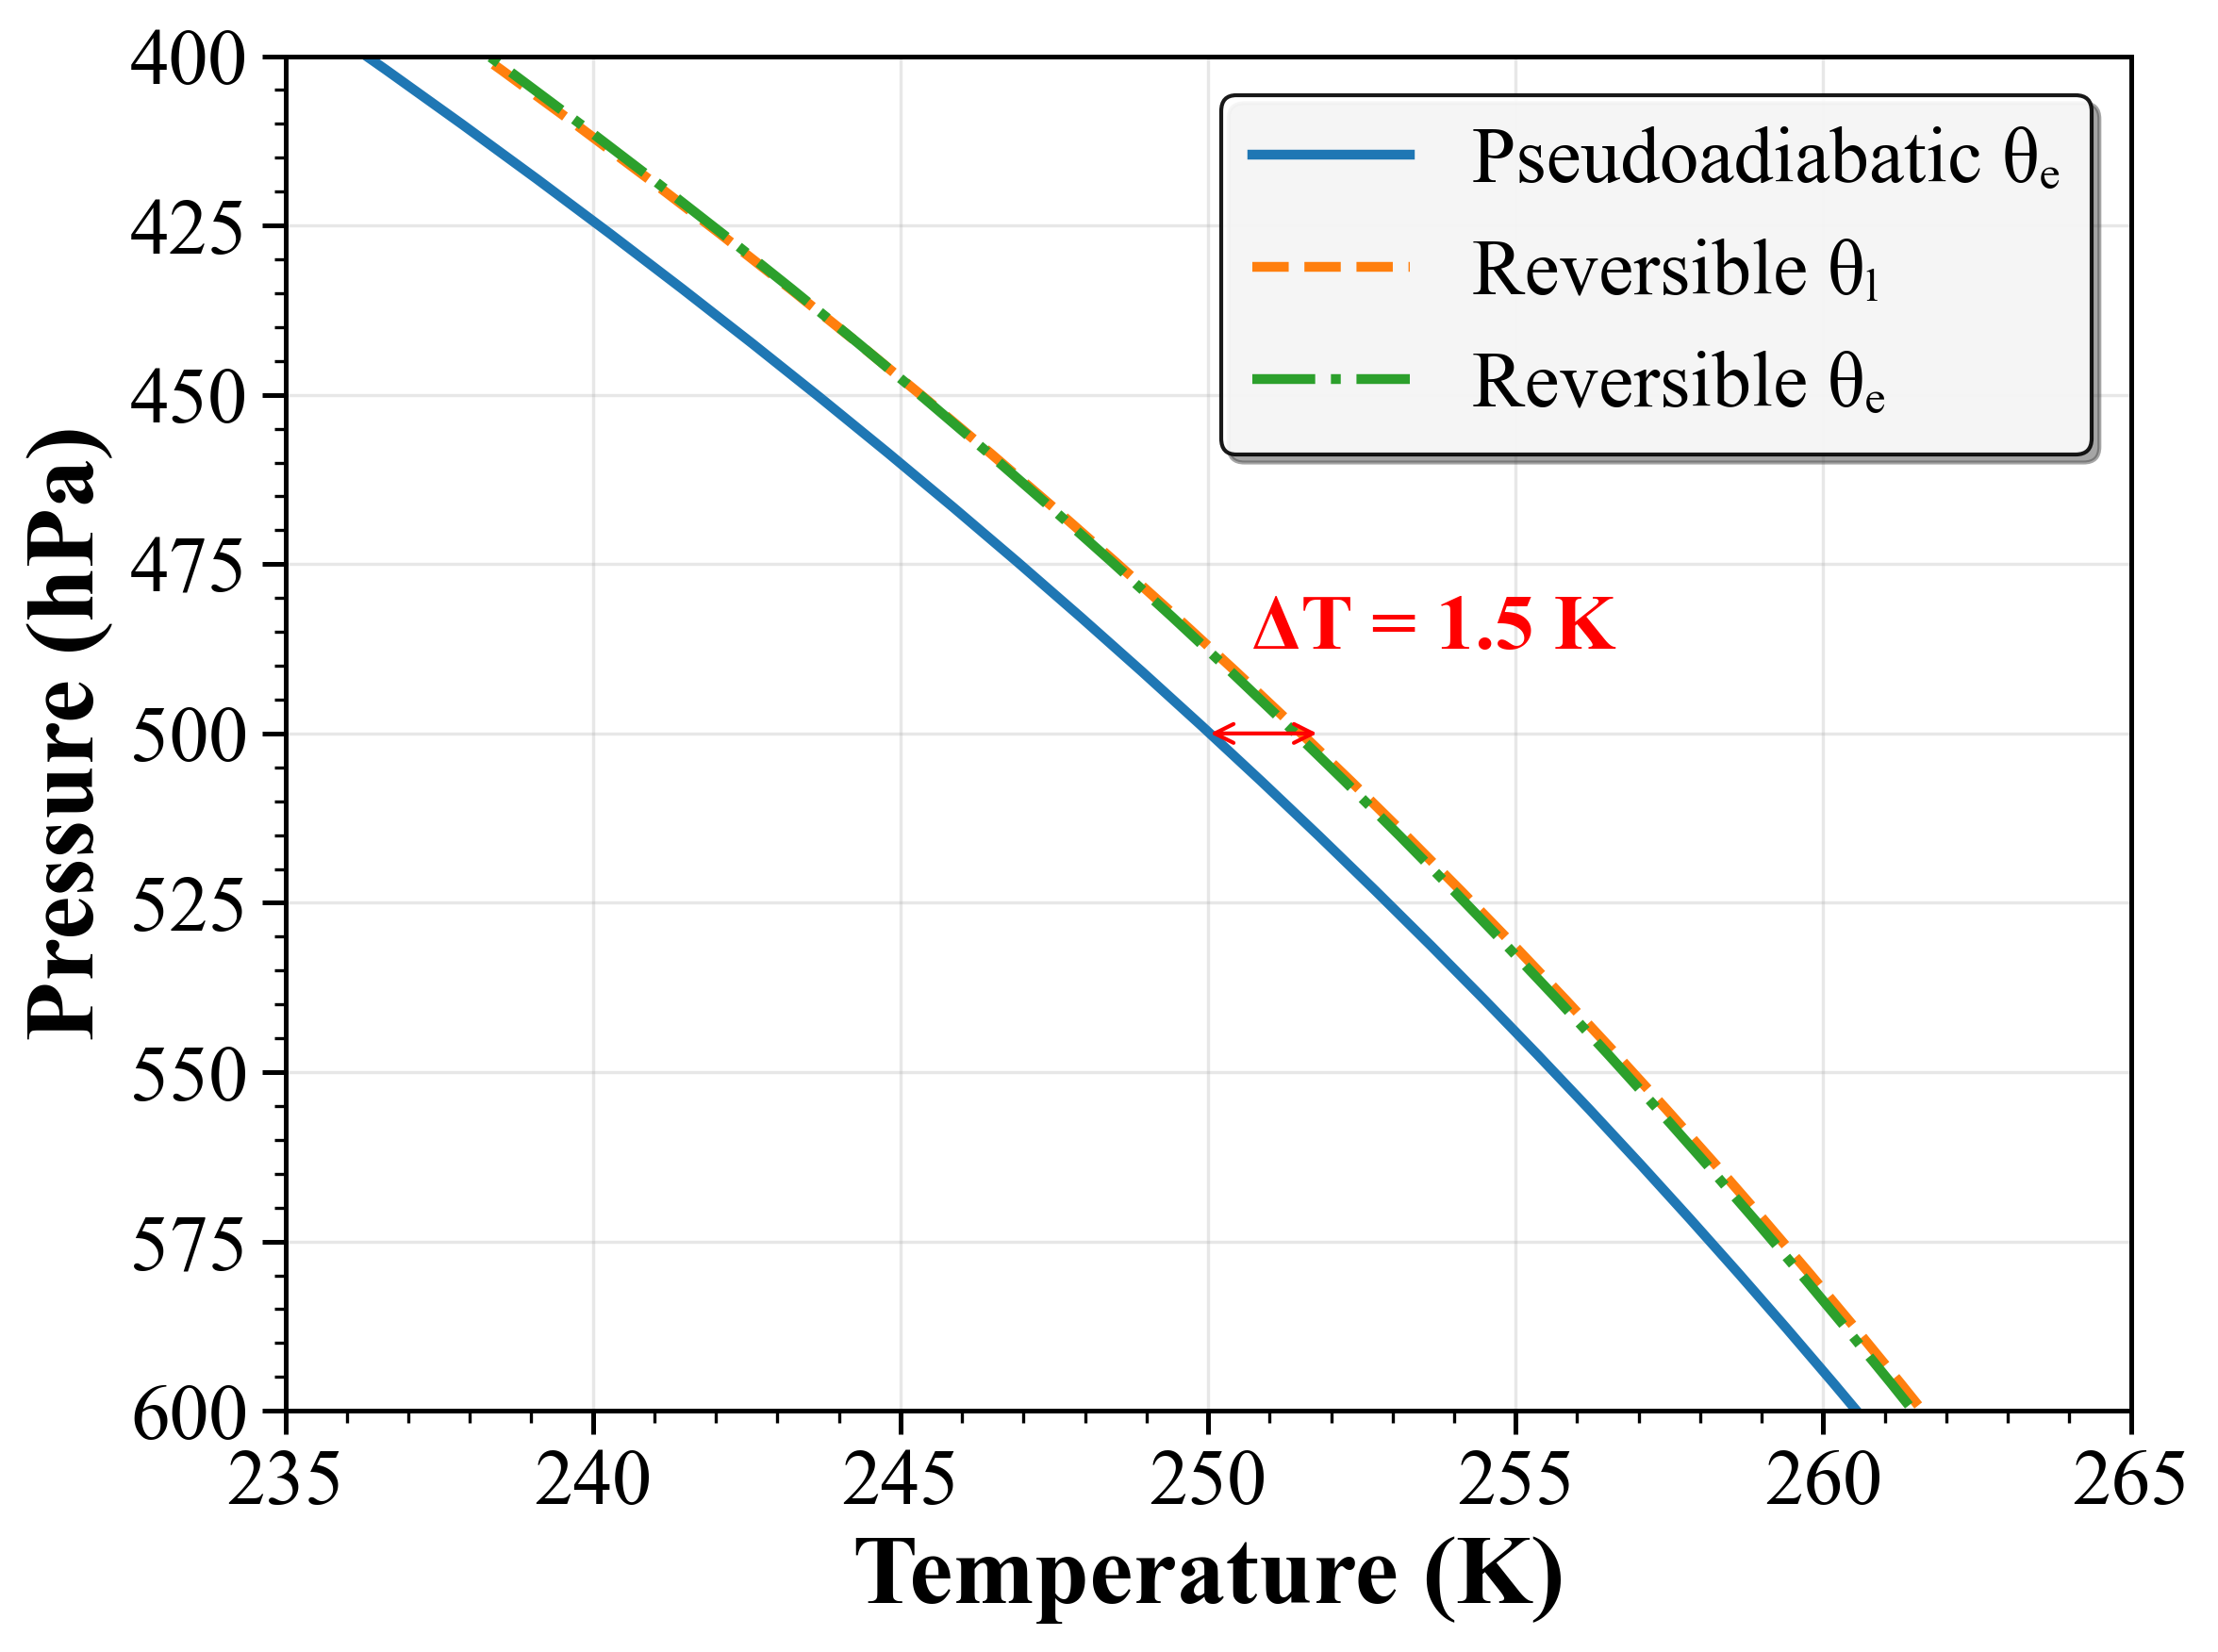

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 25,
    'axes.titlesize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

fig, ax = plt.subplots(figsize=(8, 6))

# Your original plots
ax.plot(T_pseudo, p_pseudo / 100, linewidth=2.5, color='#1f77b4', label='Pseudoadiabatic θₑ')
ax.plot(T_l, p_l / 100, linewidth=2.5, color='#ff7f0e', linestyle='--', label='Reversible θₗ')
ax.plot(T_e, p_e / 100, linewidth=2.5, color='#2ca02c', linestyle='-.', label='Reversible θₑ')

# Add ΔT annotations at 300 hPa
target_pressure = 500  # hPa

# Find the closest indices to 300 hPa for each profile
idx_pseudo = np.argmin(np.abs(p_pseudo / 100 - target_pressure))
idx_rev = np.argmin(np.abs(p_l / 100 - target_pressure))
idx_l = np.argmin(np.abs(p_e / 100 - target_pressure))

# Get temperatures at 300 hPa for each profile
T_pseudo_300 = T_pseudo[idx_pseudo]
T_l_300 = T_l[idx_rev] 
T_e_300 = T_e[idx_l]

# Add horizontal arrows and ΔT annotations
# Arrow from pseudoadiabatic to reversible θₗ
#ax.annotate('', xy=(T_rev_300, target_pressure), xytext=(T_pseudo_300, target_pressure),
            #arrowprops=dict(arrowstyle='<->', color='red', lw=2))

# ΔT text annotation above the arrow
mid_T_rev = (T_pseudo_300 + T_l_300) / 2
ax.text(mid_T_rev+3, target_pressure - 10, f'ΔT = {abs(T_l_300 - T_pseudo_300):.1f} K', 
        ha='center', va='bottom', color='red', fontweight='bold', fontsize=20)

#Arrow from pseudoadiabatic to reversible θₑ  
ax.annotate('', xy=(T_l_300+0.5, target_pressure), xytext=(T_pseudo_300, target_pressure),
            arrowprops=dict(arrowstyle='<->', color='red', lw=1))

# ΔT text annotation above the second arrow
#mid_T_l = (T_pseudo_300 + T_l_300) / 2
#ax.text(mid_T_l, target_pressure + 5, f'ΔT = {abs(T_l_300 - T_pseudo_300):.1f} K', 
        #ha='center', va='bottom', color='red', fontweight='bold', fontsize=12)

# Improved formatting
ax.invert_yaxis()
ax.set_xlabel('Temperature (K)', fontweight='bold')
ax.set_ylabel('Pressure (hPa)', fontweight='bold')
#ax.set_title('Temperature Profiles for Adiabatic Approaches', fontweight='bold', pad=20)

# Better axis limits and ticks
ax.set_ylim(600, 400)  # Note: inverted, so high to low
ax.set_xlim(235, 265)  # Adjust based on your data range

# Professional grid
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)  # Grid behind data

# Improved legend
legend = ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True,
                   framealpha=0.9, edgecolor='black', facecolor='white')

# Add minor ticks
ax.minorticks_on()
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

# Tight layout
plt.tight_layout()

plt.show()

# Reset rcParams to default after plotting (optional)
plt.rcParams.update(plt.rcParamsDefault)